In [2]:
import pandas as pd
df = pd.read_csv(r'C:\Users\perki\Downloads\archive\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check how many customers have churned
print("--- Churn Breakdown ---")
print(df['Churn'].value_counts())

# See the percentage breakdown
print("\n--- Churn Percentage ---")
print(df['Churn'].value_counts(normalize=True) * 100)

--- Churn Breakdown ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- Churn Percentage ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


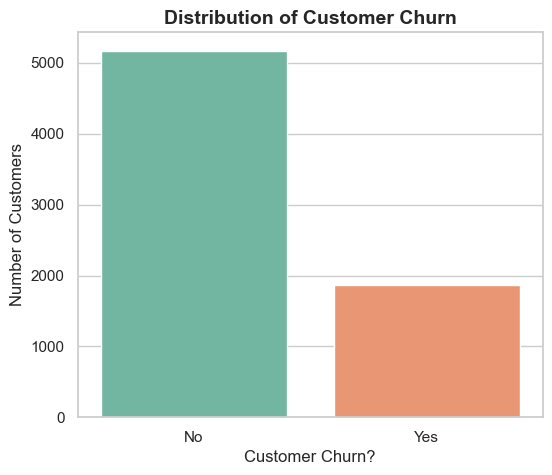

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean styling theme for our chart
sns.set_theme(style="whitegrid")

# Create the figure box size
plt.figure(figsize=(6, 5))

# Plot the customer churn counts using a bar chart
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)

# Add clear labels and a title
plt.title('Distribution of Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Customer Churn?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Display the final plot
plt.show()

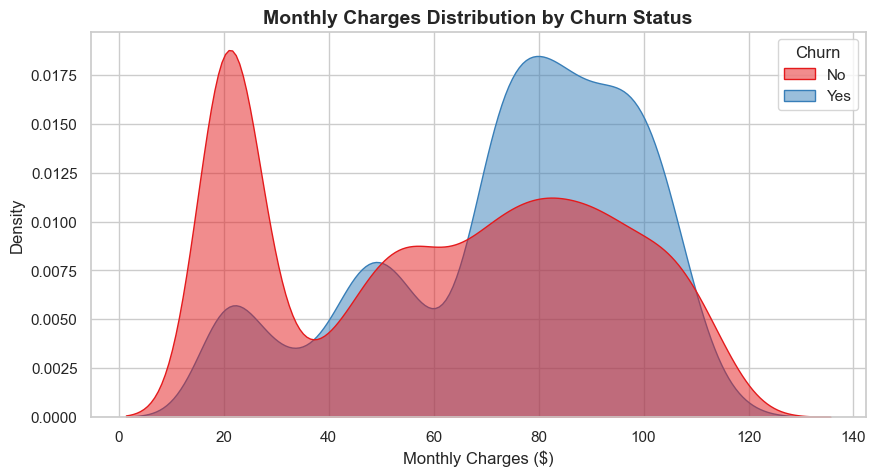

In [5]:
# Create the figure box size
plt.figure(figsize=(10, 5))

# Plot the distribution of Monthly Charges for churned vs retained customers
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='Set1', alpha=0.5)

# Add clear labels and a title
plt.title('Monthly Charges Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Display the final plot
plt.show()

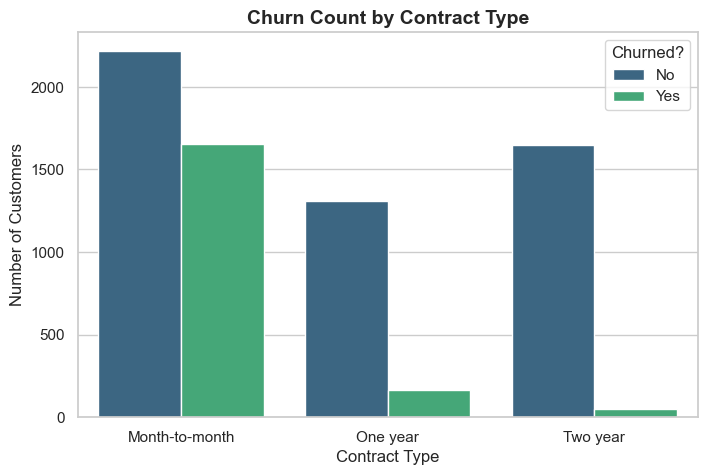

In [6]:
plt.figure(figsize=(8, 5))

# Create a bar chart showing churn rates across different contract types
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')

# Add clear labels and a title
plt.title('Churn Count by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churned?')

plt.show()

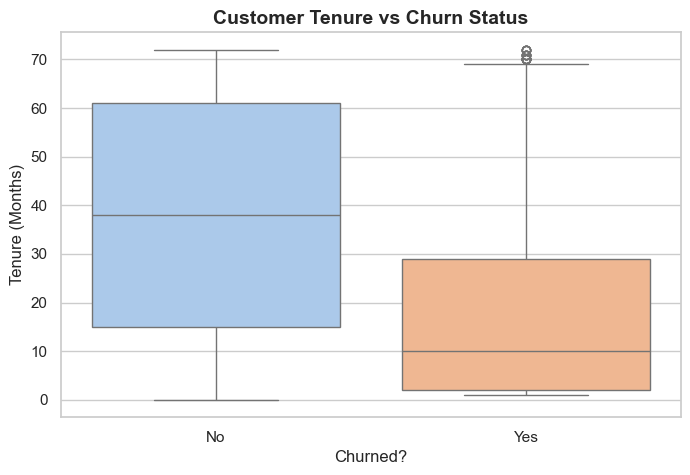

In [7]:
plt.figure(figsize=(8, 5))

# Create a boxplot to show the distribution of tenure for churned vs retained customers
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette='pastel', legend=False)

# Add clear labels and a title
plt.title('Customer Tenure vs Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churned?', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)

plt.show()

In [8]:
# Calculate the exact numerical averages for churned vs retained customers
summary = df.groupby('Churn')[['tenure', 'MonthlyCharges']].mean()

print("--- Data Summary Averages ---")
print(summary)

--- Data Summary Averages ---
          tenure  MonthlyCharges
Churn                           
No     37.569965       61.265124
Yes    17.979133       74.441332


In [9]:
import pandas as pd
import numpy as np

# 1. Convert TotalCharges to numbers, turning blank spaces into missing values (NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check how many missing values we now have
print("--- Missing Values Found ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 3. Fill those missing values with the average of the column so our data is complete
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

print("\n✓ Data successfully cleaned and missing values fixed!")

--- Missing Values Found ---
TotalCharges    11
dtype: int64

✓ Data successfully cleaned and missing values fixed!


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Select the features we want to use for prediction
# We'll convert the 'Contract' text into numbers (0, 1, 2) so the model can read it
df['Contract_Code'] = df['Contract'].astype('category').cat.codes
X = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Code']]
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Split the data into a training set (80%) and a testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Test the model's predictions
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("--- AI Model Performance ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

--- AI Model Performance ---
Overall Accuracy: 80.41%


In [11]:
# Extract the importance weights (coefficients) from the model
importance = model.coef_[0]

# Create a clean breakdown table
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Weight': importance
}).sort_values(by='Importance Weight', key=abs, ascending=False)

print("--- What the AI Cares About Most ---")
print(features_df.to_string(index=False))

--- What the AI Cares About Most ---
       Feature  Importance Weight
 Contract_Code          -1.046957
        tenure          -0.048467
MonthlyCharges           0.024341
  TotalCharges           0.000176


In [12]:
# Save the cleaned data to a new CSV file
df.to_csv('Cleaned_Telco_Customer_Churn.csv', index=False)

print("🎉 Success! Your cleaned dataset has been saved as 'Cleaned_Telco_Customer_Churn.csv'.")
print("Check your VS Code left sidebar to see it!")

🎉 Success! Your cleaned dataset has been saved as 'Cleaned_Telco_Customer_Churn.csv'.
Check your VS Code left sidebar to see it!


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Added recall_score to the imports
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score 

# 1. Re-split the data (using X and y from your earlier cells)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Recalculate original Logistic Regression metrics
logistic_preds = model.predict(X_test)
logistic_acc = accuracy_score(y_test, logistic_preds)
logistic_rec = recall_score(y_test, logistic_preds) # Added Recall
logistic_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# 3. Initialize the new models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')

# 4. Train and evaluate the Random Forest Model
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_rec = recall_score(y_test, rf_preds) # Added Recall
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

# 5. Train and evaluate the XGBoost Model
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_rec = recall_score(y_test, xgb_preds) # Added Recall
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

# 6. Print out the leaderboard (Updated to include Recall)
print("--- Final Model Leaderboard ---")
print(f"Logistic Regression -> Accuracy: {logistic_acc * 100:.2f}% | Recall: {logistic_rec * 100:.2f}% | ROC-AUC: {logistic_auc:.4f}")
print(f"Random Forest       -> Accuracy: {rf_acc * 100:.2f}% | Recall: {rf_rec * 100:.2f}% | ROC-AUC: {rf_auc:.4f}")
print(f"XGBoost             -> Accuracy: {xgb_acc * 100:.2f}% | Recall: {xgb_rec * 100:.2f}% | ROC-AUC: {xgb_auc:.4f}")

--- Final Model Leaderboard ---
Logistic Regression -> Accuracy: 80.41% | Recall: 52.55% | ROC-AUC: 0.8497
Random Forest       -> Accuracy: 76.58% | Recall: 46.92% | ROC-AUC: 0.7976
XGBoost             -> Accuracy: 80.34% | Recall: 50.13% | ROC-AUC: 0.8445


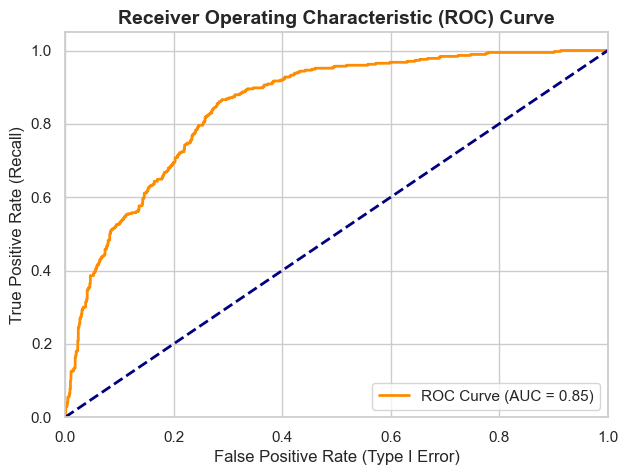

--- ROC-AUC Score: 0.8497 ---


In [14]:
from sklearn.metrics import roc_auc_score, roc_curve

# 1. Get the predicted probabilities for the positive class (Churn = Yes)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Calculate the ROC-AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)

# 3. Calculate points for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 4. Plot the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Type I Error)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

print(f"--- ROC-AUC Score: {auc_score:.4f} ---")